In [1]:
install.packages("Hmisc")
library(Hmisc)
install.packages("tseries")
library(tseries)
install.packages("car")
library(car)
install.packages("forecast")
library(forecast)
install.packages("readxl")
library(readxl)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:base’:

    format.pval, units


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData

Installing package 

In [8]:
data_r <- read_excel("/content/data_r.xlsx")
data_r_test <- read_excel("/content/data_r_test.xlsx")
head(data_r)
head(data_r_test)

date,meantemp,humidity,wind_speed,meanpressure
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>
2013-01-01,10.000000,84.50000,0.000000,1015.667
2013-01-02,7.400000,92.00000,2.980000,1017.800
2013-01-03,7.166667,87.00000,4.633333,1018.667
2013-01-04,8.666667,71.33333,1.233333,1017.167
2013-01-05,6.000000,86.83333,3.700000,1016.500
2013-01-06,7.000000,82.80000,1.480000,1018.000


date,meantemp,humidity,wind_speed,meanpressure
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>
2017-01-01,15.91304,85.86957,2.743478,59.000
2017-01-02,18.50000,77.22222,2.894444,1018.278
2017-01-03,17.11111,81.88889,4.016667,1018.333
2017-01-04,18.70000,70.05000,4.545000,1015.700
2017-01-05,18.38889,74.94444,3.300000,1014.333
2017-01-06,19.31818,79.31818,8.681818,1011.773


In [9]:
class(data_r)
class(data_r_test)

[1] "tbl_df"     "tbl"        "data.frame"

[1] "tbl_df"     "tbl"        "data.frame"

In [10]:
# Checking for missing values in both series

colSums(is.na(data_r))
colSums(is.na(data_r_test))

date     meantemp     humidity   wind_speed meanpressure 
           0            0            0            0            0

date     meantemp     humidity   wind_speed meanpressure 
           0            0            0            0            0

In [11]:
# Converting 'data_r' to time series and storing in 'climate'

climate <- ts(data_r[, 2:5],
              start = c(2013, 1),
              frequency = 365)

temperature <- ts(data_r$meantemp,
                  start = c(2013, 1),
                  frequency = 365)

humidity <- ts(data_r$humidity,
               start = c(2013, 1),
               frequency = 365)

wind_speed <- ts(data_r$wind_speed,
                 start = c(2013, 1),
                 frequency = 365)

pressure <- ts(data_r$meanpressure,
               start = c(2013, 1),
               frequency = 365)


[1] "mts"    "ts"     "matrix" "array"

[1] "tbl_df"     "tbl"        "data.frame"

[1] "ts"

[1] "ts"

[1] "ts"

[1] "ts"

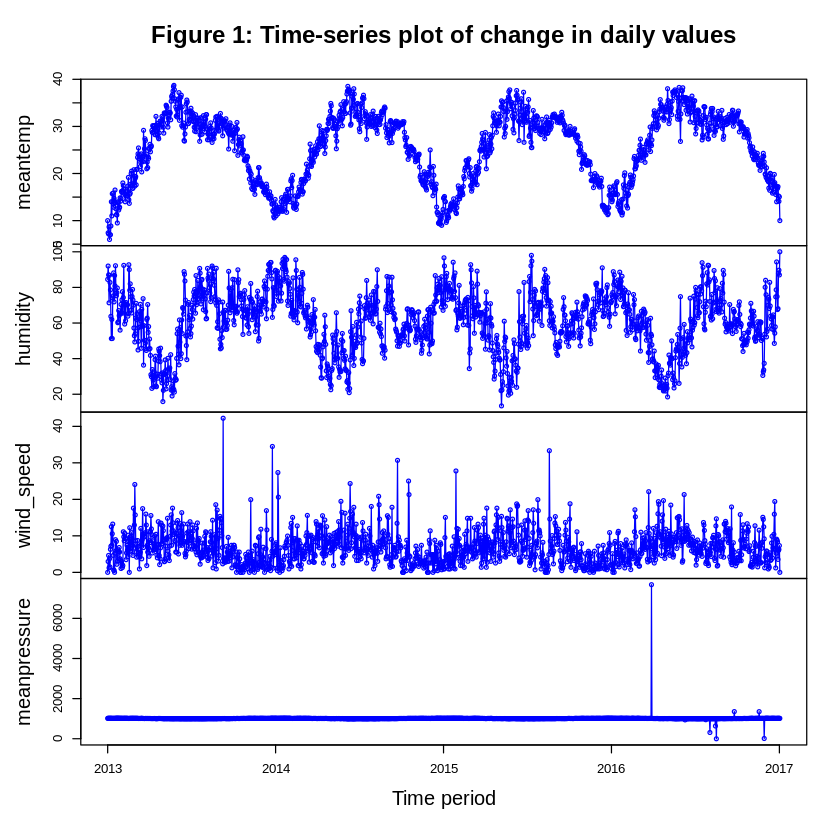

In [12]:
# Checking conversion has been successfully done for each series

class(climate)
class(data_r)
class(pressure)
class(wind_speed)
class(humidity)
class(temperature)


plot(climate, ylab='climate_data', xlab='Time period', type='o',
     col='blue', main = 'Figure 1: Time-series plot of change in daily values')


In [13]:
# ++++++++++++++++++++++++++++
# flattenCorrMatrix
# ++++++++++++++++++++++++++++
# cormat : matrix of the correlation coefficients
# pmat : matrix of the correlation p-values

flattenCorrMatrix <- function(cormat, pmat) {
  ut <- upper.tri(cormat)
  data.frame(
    row = rownames(cormat)[row(cormat)[ut]],
    column = rownames(cormat)[col(cormat)[ut]],
    cor  =(cormat)[ut],
    p = pmat[ut]
  )
}

In [14]:
# Calculating correlation

res1<-rcorr(as.matrix(climate))
flattenCorrMatrix(res1$r, res1$P)

row,column,cor,p
<chr>,<chr>,<dbl>,<dbl>
meantemp,humidity,-0.571950716,0.0000000
meantemp,wind_speed,0.306467711,0.0000000
humidity,wind_speed,-0.373971675,0.0000000
meantemp,meanpressure,-0.038818184,0.1379294
humidity,meanpressure,0.001733735,0.9471910
wind_speed,meanpressure,-0.020669621,0.4296830


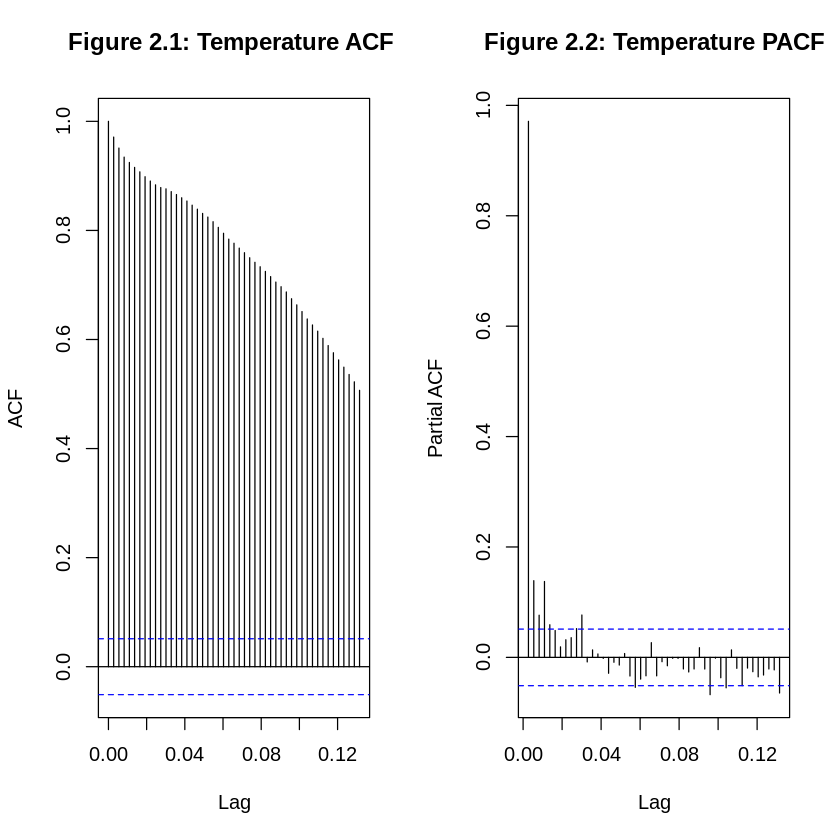

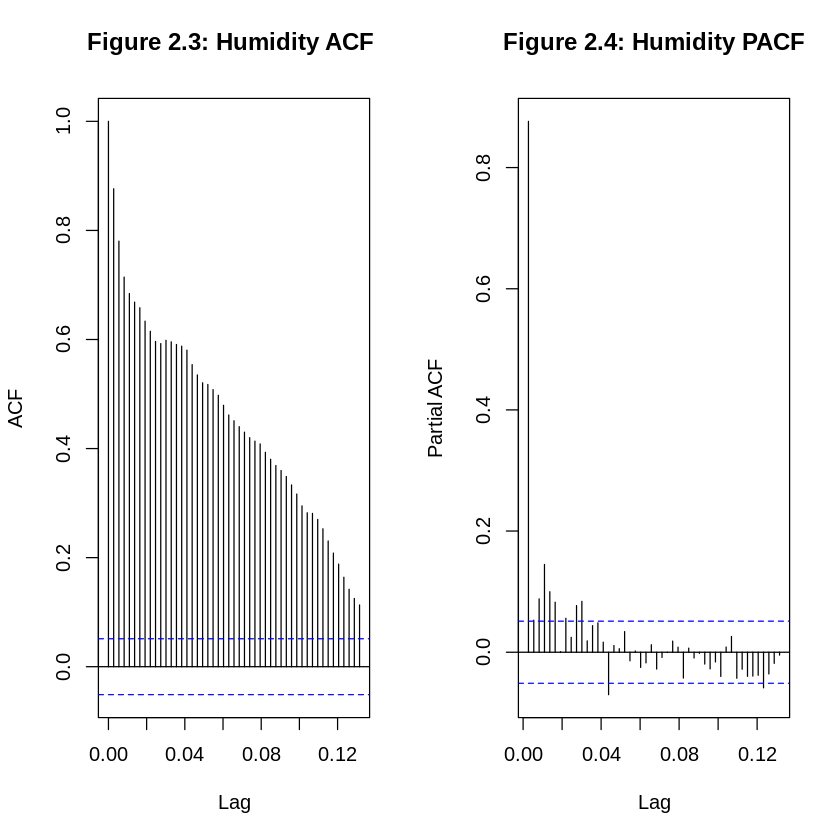

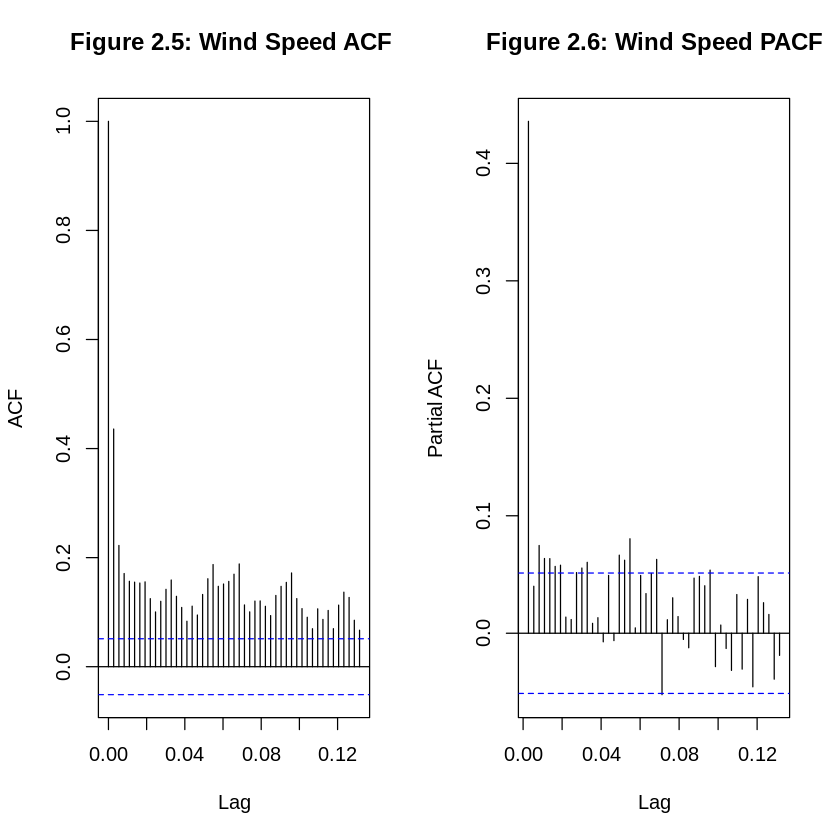

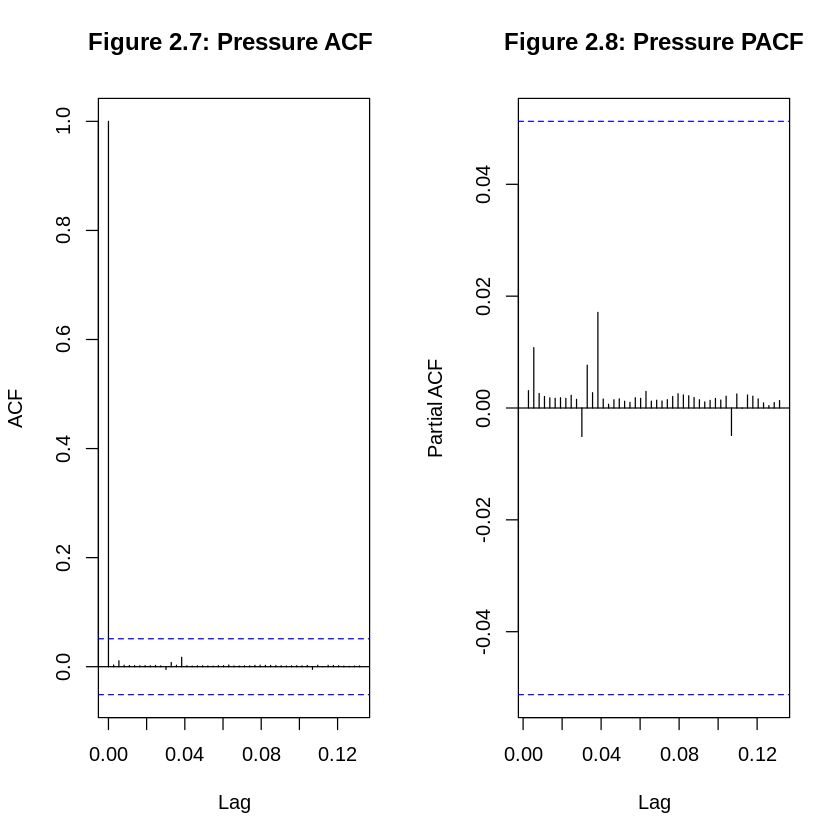

In [15]:
# Plotting ACF and PACF
par(mfrow=c(1,2))
acf(temperature, lag.max = 48, main = "Figure 2.1: Temperature ACF ")
pacf(temperature, lag.max = 48, main = "Figure 2.2: Temperature PACF")
# Temperature is non-stationary

par(mfrow=c(1,2))
acf(humidity, lag.max = 48, main = "Figure 2.3: Humidity ACF ")
pacf(humidity, lag.max = 48, main = "Figure 2.4: Humidity PACF")
# Humidity is non-stationary

par(mfrow=c(1,2))
acf(wind_speed, lag.max = 48, main = "Figure 2.5: Wind Speed ACF ")
pacf(wind_speed, lag.max = 48, main = "Figure 2.6: Wind Speed PACF")
#Wind speed is stationary

acf(pressure, lag.max = 48, main = "Figure 2.7: Pressure ACF ")
pacf(pressure, lag.max = 48, main = "Figure 2.8: Pressure PACF")
#Pressure is fully stationary

In [16]:
#Dicker-Fuller Unit-Root test (ADF)

adf.test(temperature, k=ar(temperature)$order)
#The ADF test of 11 lag order for FFD indicates series is non-stationary as p-value is greater than 5% level of significance.

adf.test(humidity, k=ar(humidity)$order)
#The ADF test rejects the null hypothesis of a unit root at the 5% level (p = 0.036), indicating that humidity is stationary.

adf.test(wind_speed, k=ar(wind_speed)$order)
#The ADF test of 0 lag order for wind speed indicates series is stationary as p-value is less than 5% level of significance supporting the ACF & PACF plots plotted for it.

adf.test(pressure, k=ar(pressure)$order)
#The ADF test of 0 lag order for wind speed indicates series is stationary as p-value is less than 5% level of significance supporting the ACF & PACF plots plotted for it.



	Augmented Dickey-Fuller Test

data:  temperature
Dickey-Fuller = -1.8526, Lag order = 11, p-value = 0.6407
alternative hypothesis: stationary



	Augmented Dickey-Fuller Test

data:  humidity
Dickey-Fuller = -3.5628, Lag order = 16, p-value = 0.03626
alternative hypothesis: stationary



	Augmented Dickey-Fuller Test

data:  wind_speed
Dickey-Fuller = -3.9579, Lag order = 26, p-value = 0.0111
alternative hypothesis: stationary


Warning message in adf.test(pressure, k = ar(pressure)$order):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  pressure
Dickey-Fuller = -38.073, Lag order = 0, p-value = 0.01
alternative hypothesis: stationary


Warning message in adf.test(temperature_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  temperature_diff
Dickey-Fuller = -14.011, Lag order = 11, p-value = 0.01
alternative hypothesis: stationary


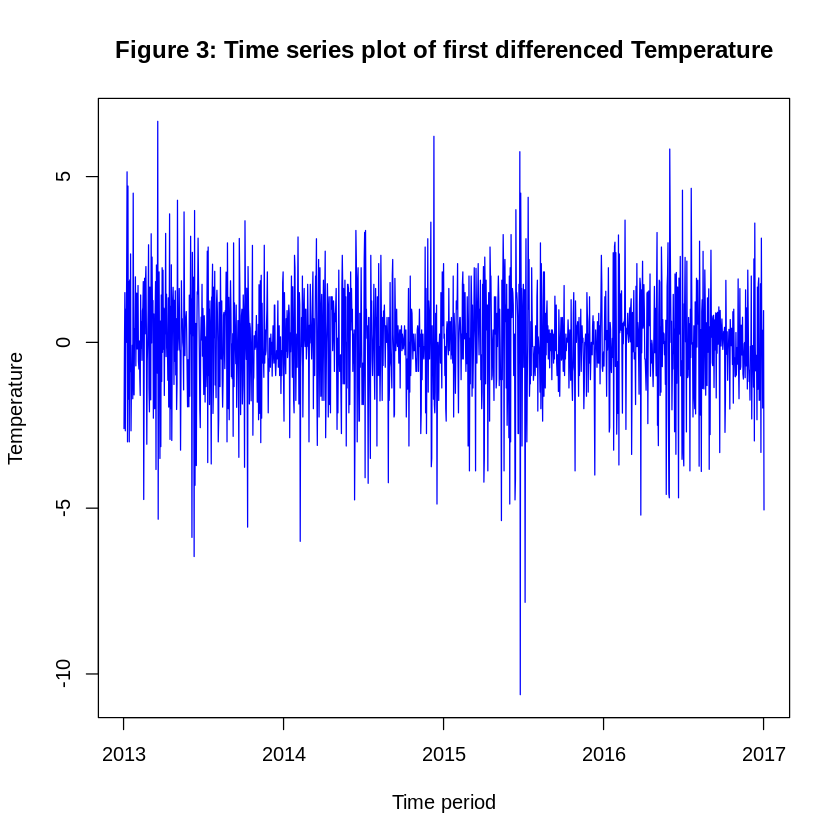

In [17]:
#Transformation of Temperature (non-stationary)
temperature_diff = diff(temperature)
plot(temperature_diff,ylab='Temperature',xlab='Time period', col="blue",
     main = "Figure 3: Time series plot of first differenced Temperature")

#Performing ADF test to check stationarity of first order differenced Temperature:
adf.test(temperature_diff)


In [19]:
#Applying finiteDLMauto to calculate best model based on AIC, BIC and MASE values
install.packages("dLagM")
library(dLagM)

finiteDLMauto( x=as.vector(humidity), y= as.vector(temperature), q.min = 1, q.max = 10,
               model.type="dlm", error.type = "AIC",trace=TRUE)

model.humidity = dlm(x=as.vector(humidity), y=as.vector(temperature), q=10)
model.wind_speed = dlm(x=as.vector(wind_speed), y=as.vector(temperature), q=10)
model.pressure = dlm(x=as.vector(pressure), y=as.vector(temperature), q=10)

AIC(model.humidity$model,model.wind_speed$model,
               model.pressure$model)

BIC(model.humidity$model,model.wind_speed$model,
    model.pressure$model)

MASE(model.humidity$model,model.wind_speed$model,
     model.pressure$model)

model.finite2 = dlm(x=as.vector(humidity), y=as.vector(temperature), q=10)
summary(model.finite2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gtools’, ‘operator.tools’, ‘RcppParallel’, ‘nardl’, ‘dynlm’, ‘AER’, ‘formula.tools’, ‘plyr’, ‘strucchange’, ‘wavethresh’, ‘roll’, ‘sandwich’


Loading required package: nardl

Loading required package: dynlm

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘dLagM’


The following object is masked from ‘package:forecast’:

    forecast




,q - k,MASE,AIC,BIC,GMRAE,MBRAE,R.Adj.Sq,Ljung-Box
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10,10,3.97711,9213.250,9281.899,7.79574,0.38500,0.36916,0
9,9,3.98282,9226.722,9290.099,7.82593,0.05357,0.36696,0
8,8,3.99114,9240.265,9298.367,7.70767,1.06524,0.36407,0
7,7,4.00205,9259.063,9311.891,7.78405,-0.32448,0.36007,0
6,6,4.01565,9278.410,9325.961,7.62862,3.88361,0.35635,0
5,5,4.03545,9297.370,9339.643,7.88619,0.92338,0.35277,0
4,4,4.05029,9314.954,9351.948,7.89898,0.73404,0.35009,0
3,3,4.06283,9334.360,9366.073,7.89758,0.98564,0.34576,0
2,2,4.08350,9357.638,9384.069,7.82534,-0.69639,0.34010,0


,df,AIC
,<dbl>,<dbl>
model.humidity$model,13,9213.25
model.wind_speed$model,13,9308.50
model.pressure$model,13,9885.48


,df,BIC
,<dbl>,<dbl>
model.humidity$model,13,9281.899
model.wind_speed$model,13,9377.149
model.pressure$model,13,9954.129


,n,MASE
,<dbl>,<dbl>
model.humidity$model,1452,3.977112
model.wind_speed$model,1452,3.916263
model.pressure$model,1452,5.074075



Call:
lm(formula = model.formula, data = design)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.9457  -4.5412  -0.8068   4.8329  12.1744 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 43.991536   0.653630  67.303  < 2e-16 ***
x.t         -0.143223   0.019467  -7.357 3.14e-13 ***
x.1          0.003064   0.024776   0.124   0.9016    
x.2         -0.014673   0.024752  -0.593   0.5534    
x.3         -0.015644   0.024738  -0.632   0.5272    
x.4         -0.010474   0.024757  -0.423   0.6723    
x.5         -0.005668   0.024730  -0.229   0.8188    
x.6         -0.015174   0.024753  -0.613   0.5400    
x.7         -0.016085   0.024709  -0.651   0.5152    
x.8         -0.021076   0.024778  -0.851   0.3951    
x.9         -0.014769   0.024787  -0.596   0.5514    
x.10        -0.049395   0.019490  -2.534   0.0114 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.748 on 1440 degrees of freedom
Mul

In [20]:
vif(model.finite2$model)

x.t      x.1      x.2      x.3      x.4      x.5      x.6      x.7 
4.667262 7.531705 7.505762 7.481451 7.485348 7.477336 7.503057 7.474576 
     x.8      x.9     x.10 
7.508305 7.526236 4.657521

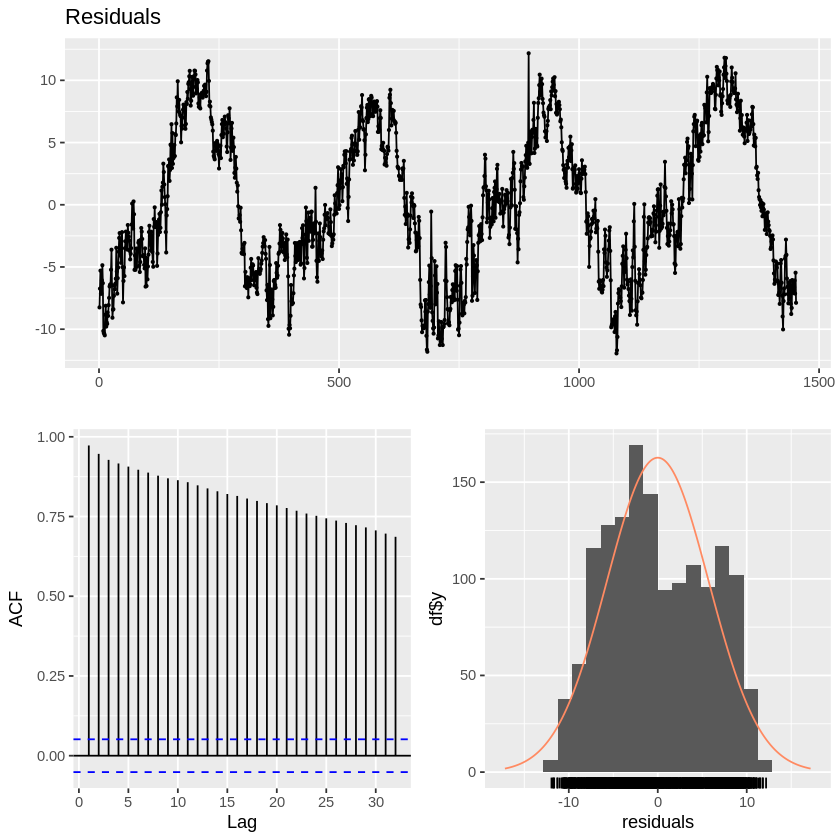

In [22]:
#Residual analysis of model.finite2 model
checkresiduals(model.finite2$model,test=FALSE)

In [23]:
#Forecasting using model.finite2
x <- data_r_test[,3]
x

humidity
<dbl>
85.86957
77.22222
81.88889
70.05000
74.94444
79.31818
95.83333
83.52632
80.80952


In [33]:
# Generating prediction intervals & point forecasts
fit <- auto.arima(humidity) #Since humidity is the variable that best fits the model
fc <- forecast::forecast(fit, h = 4*365)

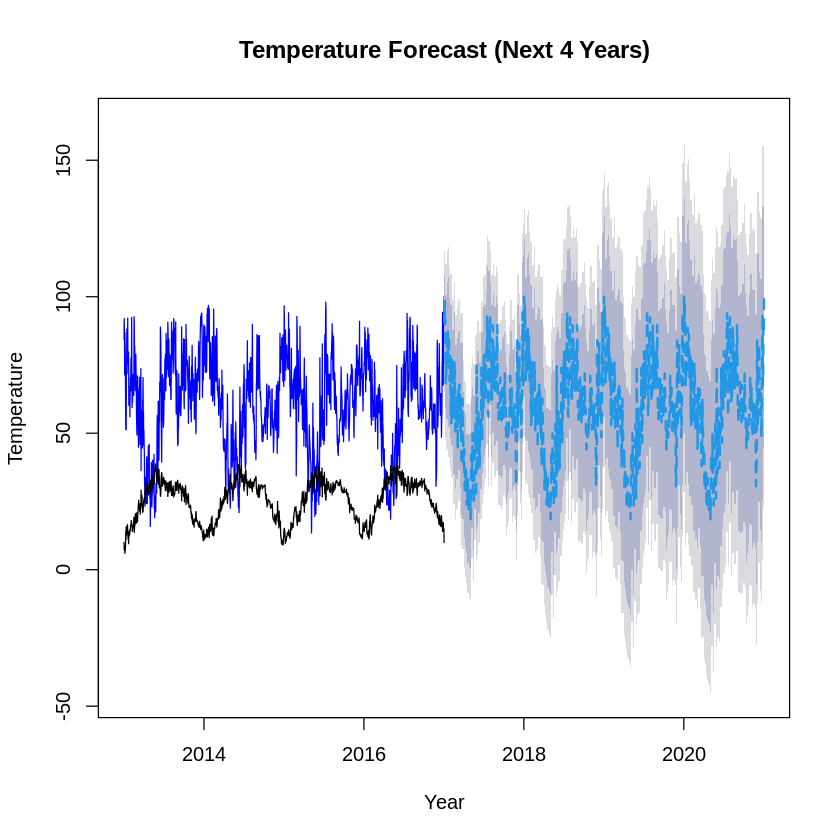

In [34]:
plot(fc,
     main = "Temperature Forecast (Next 4 Years)",
     xlab = "Year",
     ylab = "Temperature",
     col = "blue",
     flty = 2)   # dashed forecast line

lines(temperature, col = "black")